,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Jumlah baris: 9,994 | Pelanggan unik: 793


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary
Customer_Segment,,,,,
Loyal Customers,254,75.1,7.4,3869.4,982820.8
Champions,124,28.1,9.4,5221.2,647435.0
Lost,171,377.5,3.7,1684.1,287983.0
At Risk,90,243.8,6.8,1995.9,179630.8
Needs Attention,78,77.0,4.9,1554.0,121208.9
Potential Loyalist,76,28.1,4.3,1027.9,78122.4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

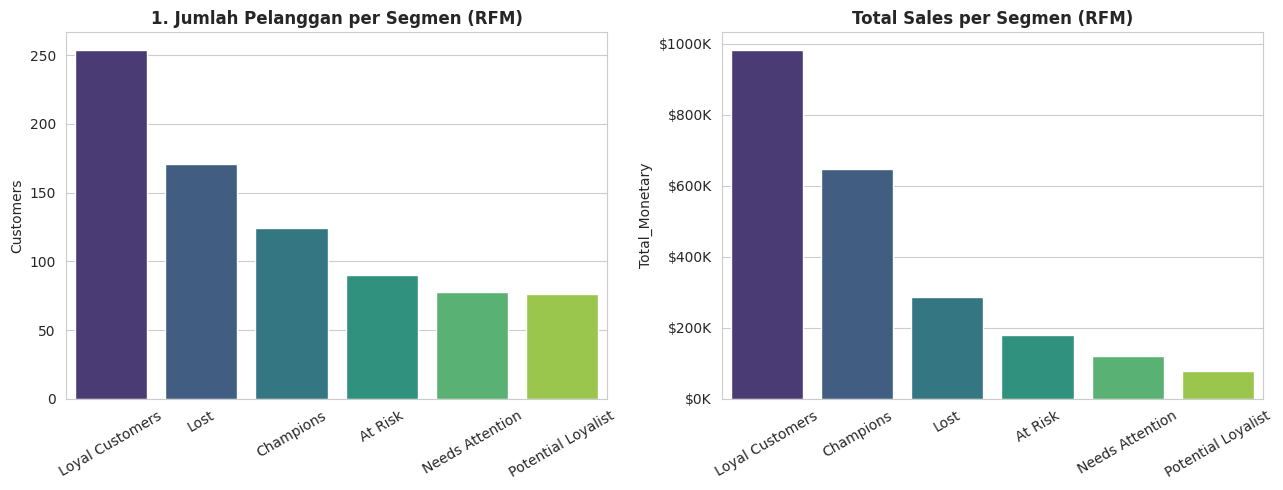

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

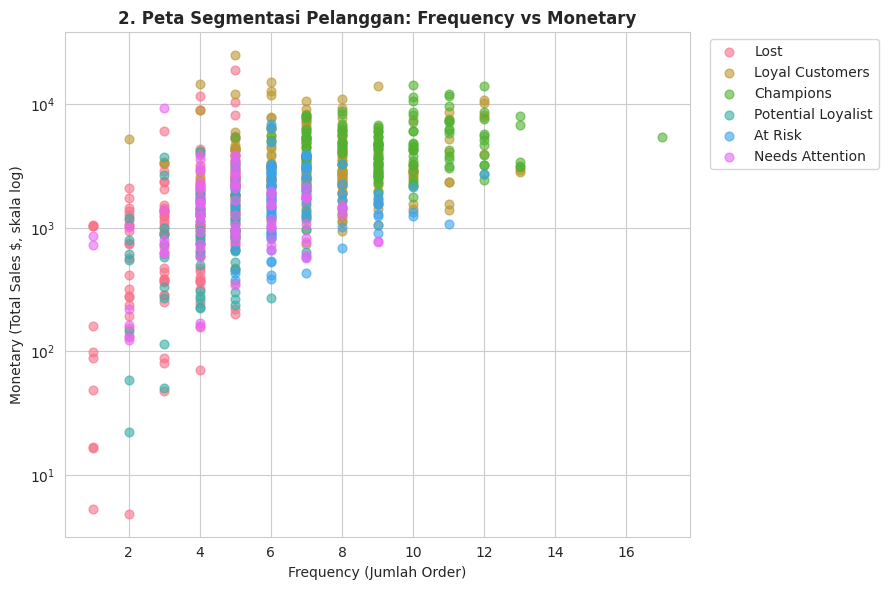

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Segment,Total_Sales,Total_Profit,Orders,Customers,Profit_Margin_%,Avg_Order_Value
0,Consumer,1.161401e+06,134119.2092,2586,409,11.55,449.11
1,Corporate,7.061464e+05,91979.1340,1514,236,13.03,466.41
2,Home Office,4.296531e+05,60298.6785,909,148,14.03,472.67


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

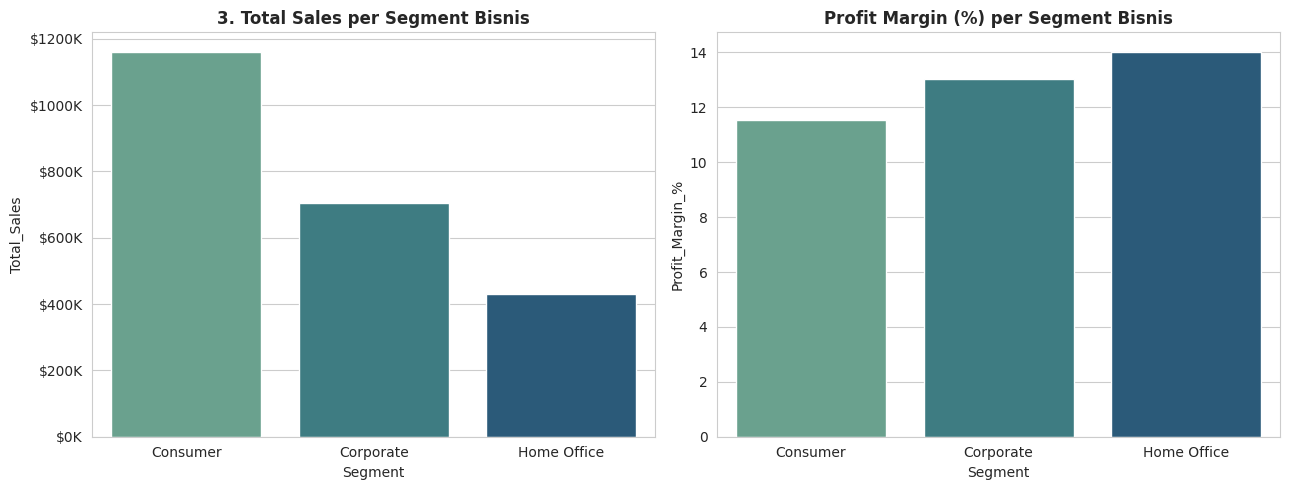

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Region,Total_Sales,Total_Profit,Orders,Profit_Margin_%
3,West,725457.8245,108418.4489,1611,14.94
1,East,678781.2400,91522.7800,1401,13.48
0,Central,501239.8908,39706.3625,1175,7.92
2,South,391721.9050,46749.4303,822,11.93


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

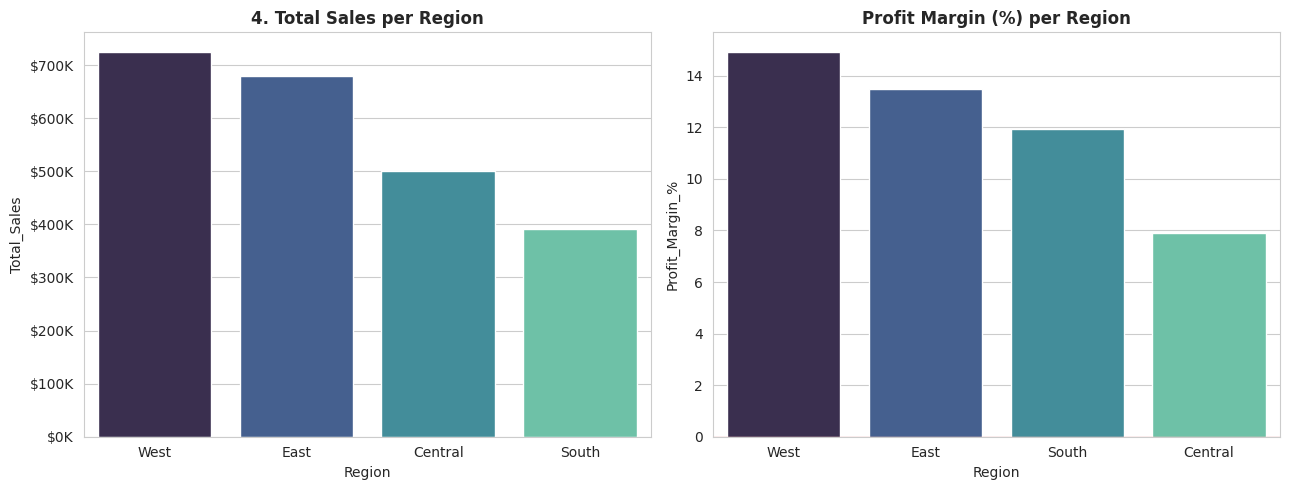

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Category,Sub-Category,Total_Sales,Total_Profit,Orders,Profit_Margin_%
3,Furniture,Tables,206965.5320,-17725.4811,307,-8.56
0,Furniture,Bookcases,114879.9963,-3472.5560,224,-3.02
12,Office Supplies,Supplies,46673.5380,-1189.0995,187,-2.55
15,Technology,Machines,189238.6310,3384.7569,112,1.79
1,Furniture,Chairs,328449.1030,26590.1663,576,8.10
11,Office Supplies,Storage,223843.6080,21278.8264,777,9.51
16,Technology,Phones,330007.0540,44515.7306,814,13.49
2,Furniture,Furnishings,91705.1640,13059.1436,877,14.24
6,Office Supplies,Binders,203412.7330,30221.7633,1316,14.86
4,Office Supplies,Appliances,107532.1610,18138.0054,451,16.87


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

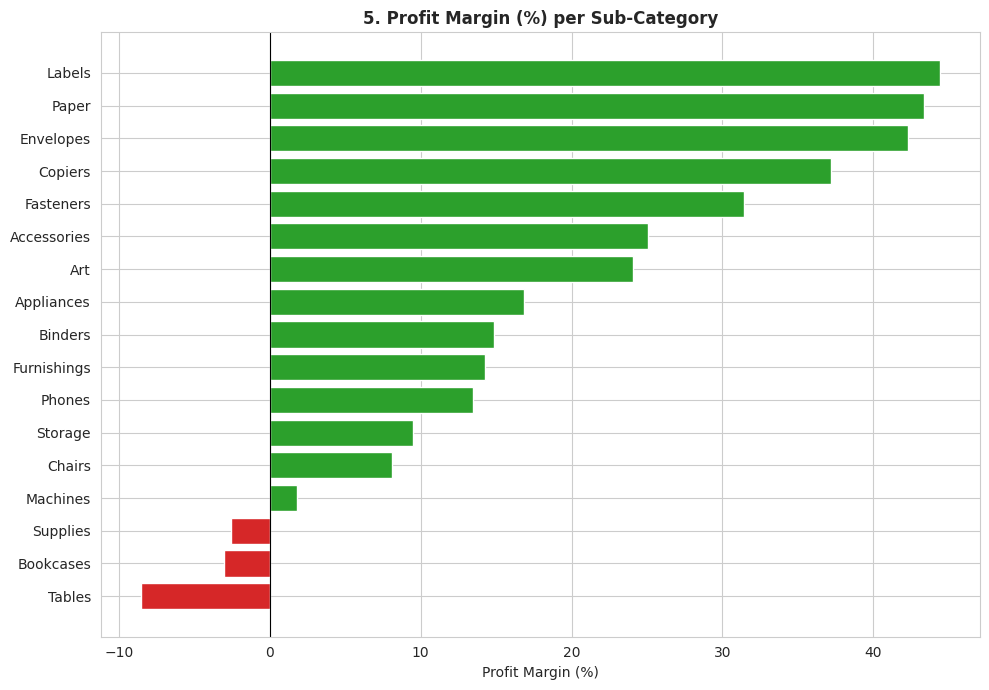

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Region,Central,East,South,West
Segment,,,,
Consumer,252031.4340,350908.167,195580.9710,362880.7730
Corporate,157995.8128,200409.347,121885.9325,225855.2745
Home Office,91212.6440,127463.726,74255.0015,136721.7770


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from google.colab import files

sns.set_style("whitegrid")

df = pd.read_csv('Sample - Superstore.csv', encoding="latin1")
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

display(df.head())
print(f"Jumlah baris: {df.shape[0]:,} | Pelanggan unik: {df['Customer ID'].nunique()}")

# ---------------------------------------------------------
# 1. RFM ANALYSIS (Customer Segmentation)
# ---------------------------------------------------------
snapshot_date = df['Order Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('Order Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment_customer(row):
    if row['RFM_Score'] >= 13:
        return 'Champions'
    elif row['RFM_Score'] >= 10:
        return 'Loyal Customers'
    elif row['R_Score'] >= 4 and row['RFM_Score'] < 10:
        return 'Potential Loyalist'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

seg_summary = rfm.groupby('Customer_Segment').agg(
    Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Monetary=('Monetary', 'sum')
).round(1).sort_values('Total_Monetary', ascending=False)

display(seg_summary)
rfm.to_csv('rfm_output.csv', index=False)
files.download('rfm_output.csv')

# ---------------------------------------------------------
# CHART 1: Jumlah Pelanggan & Total Sales per Segmen RFM
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

d1 = seg_summary.reset_index().sort_values('Customers', ascending=False)
sns.barplot(data=d1, x='Customer_Segment', y='Customers', hue='Customer_Segment',
            ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('1. Jumlah Pelanggan per Segmen (RFM)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

d2 = seg_summary.reset_index().sort_values('Total_Monetary', ascending=False)
sns.barplot(data=d2, x='Customer_Segment', y='Total_Monetary', hue='Customer_Segment',
            ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Total Sales per Segmen (RFM)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('chart1_rfm_segments.png', dpi=300)
plt.show()
files.download('chart1_rfm_segments.png')

# ---------------------------------------------------------
# CHART 2: Scatter Plot Frequency vs Monetary per Segmen
# ---------------------------------------------------------
plt.figure(figsize=(9, 6))
segs = rfm['Customer_Segment'].unique()
colors = sns.color_palette("husl", len(segs))
for seg, c in zip(segs, colors):
    d = rfm[rfm['Customer_Segment'] == seg]
    plt.scatter(d['Frequency'], d['Monetary'], label=seg, alpha=0.6, s=40, color=c)
plt.xlabel('Frequency (Jumlah Order)')
plt.ylabel('Monetary (Total Sales $, skala log)')
plt.title('2. Peta Segmentasi Pelanggan: Frequency vs Monetary', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.yscale('log')
plt.tight_layout()
plt.savefig('chart2_rfm_scatter.png', dpi=300)
plt.show()
files.download('chart2_rfm_scatter.png')

# ---------------------------------------------------------
# 2. BUSINESS SEGMENT (Consumer / Corporate / Home Office)
# ---------------------------------------------------------
biz_seg = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()
biz_seg['Profit_Margin_%'] = (biz_seg['Total_Profit'] / biz_seg['Total_Sales'] * 100).round(2)
biz_seg['Avg_Order_Value'] = (biz_seg['Total_Sales'] / biz_seg['Orders']).round(2)
display(biz_seg)
biz_seg.to_csv('business_segment_summary.csv', index=False)
files.download('business_segment_summary.csv')

# CHART 3: Sales & Margin per Segment Bisnis
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=biz_seg, x='Segment', y='Total_Sales', hue='Segment',
            ax=axes[0], palette='crest', legend=False)
axes[0].set_title('3. Total Sales per Segment Bisnis', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

sns.barplot(data=biz_seg, x='Segment', y='Profit_Margin_%', hue='Segment',
            ax=axes[1], palette='crest', legend=False)
axes[1].set_title('Profit Margin (%) per Segment Bisnis', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_business_segment.png', dpi=300)
plt.show()
files.download('chart3_business_segment.png')

# ---------------------------------------------------------
# 3. REGION SEGMENTATION
# ---------------------------------------------------------
region_seg = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
region_seg['Profit_Margin_%'] = (region_seg['Total_Profit'] / region_seg['Total_Sales'] * 100).round(2)
display(region_seg.sort_values('Total_Sales', ascending=False))
region_seg.to_csv('region_segment_summary.csv', index=False)
files.download('region_segment_summary.csv')

# CHART 4: Sales & Margin per Region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
r1 = region_seg.sort_values('Total_Sales', ascending=False)
sns.barplot(data=r1, x='Region', y='Total_Sales', hue='Region',
            ax=axes[0], palette='mako', legend=False)
axes[0].set_title('4. Total Sales per Region', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

r2 = region_seg.sort_values('Profit_Margin_%', ascending=False)
sns.barplot(data=r2, x='Region', y='Profit_Margin_%', hue='Region',
            ax=axes[1], palette='mako', legend=False)
axes[1].set_title('Profit Margin (%) per Region', fontweight='bold')
axes[1].axhline(0, color='red', linewidth=0.8)

plt.tight_layout()
plt.savefig('chart4_region_segment.png', dpi=300)
plt.show()
files.download('chart4_region_segment.png')

# ---------------------------------------------------------
# 4. CATEGORY / SUB-CATEGORY SEGMENTATION
# ---------------------------------------------------------
cat_seg = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'nunique')
).reset_index()
cat_seg['Profit_Margin_%'] = (cat_seg['Total_Profit'] / cat_seg['Total_Sales'] * 100).round(2)
display(cat_seg.sort_values('Profit_Margin_%'))
cat_seg.to_csv('category_segment_summary.csv', index=False)
files.download('category_segment_summary.csv')

# CHART 5: Profit Margin per Sub-Category
cat_sorted = cat_seg.sort_values('Profit_Margin_%')
plt.figure(figsize=(10, 7))
colors5 = ['#d62728' if x < 0 else '#2ca02c' for x in cat_sorted['Profit_Margin_%']]
plt.barh(cat_sorted['Sub-Category'], cat_sorted['Profit_Margin_%'], color=colors5)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('5. Profit Margin (%) per Sub-Category', fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.tight_layout()
plt.savefig('chart5_category_margin.png', dpi=300)
plt.show()
files.download('chart5_category_margin.png')

# ---------------------------------------------------------
# 5. RINGKASAN SEGMEN x REGION (opsional, cross-tab)
# ---------------------------------------------------------
cross = df.groupby(['Segment', 'Region'])['Sales'].sum().unstack()
display(cross)